# Google stock dataset — in-depth exploratory data analysis

This notebook looks at the **STOCKS_GOOGL** dataset used in `Hierarchical_Curriculum_and_Adaptive_Strategies_in_G_Learning (2).ipynb`. It is a standalone analysis.

## 1. Reproducible setup

Dependencies: `pandas numpy matplotlib scipy statsmodels nbformat ipykernel gym-anytrading`. Install these in the selected Python environment if needed. Random resampling below uses a fixed seed.

In [1]:
# Record package versions so the dataset and calculations can be reproduced.
import sys, platform, hashlib, importlib.metadata as metadata
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from IPython.display import display, Markdown
from gym_anytrading.datasets import STOCKS_GOOGL
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.grid': True, 'grid.alpha': .2, 'figure.dpi': 110})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda v: f'{v:,.5f}')
rng = np.random.default_rng(42)
def explain(text): display(Markdown('**Output interpretation.** ' + text))
def finish(): plt.tight_layout(); plt.show(); plt.close('all')
versions = {p: metadata.version(p) for p in ['pandas','numpy','matplotlib','scipy','statsmodels','gym-anytrading']}
display(pd.Series(versions, name='Version').to_frame())
print('Python:', platform.python_version())

,Version
pandas,3.0.5
numpy,2.4.6
matplotlib,3.11.1
scipy,1.17.1
statsmodels,0.15.0
gym-anytrading,2.0.0


Python: 3.11.4


## 2. Load the source without replacing its dates

In [2]:
# Keep the source index; resetting it would discard the real date labels.
raw = STOCKS_GOOGL.copy(deep=True)
print('Source index:', type(raw.index).__name__, '| Name:', raw.index.name)
print('Shape:', raw.shape)
print('Table SHA256:', hashlib.sha256(raw.to_csv().encode()).hexdigest())
df = raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
assert isinstance(df.index, pd.DatetimeIndex), 'Source lacks actual dates; do not invent dates.'
df.index = pd.to_datetime(df.index)
df.index.name = 'date'
assert {'open','high','low','close','adj_close','volume'} <= set(df.columns)
display(df.head()); display(df.tail())
explain(f'The source contains **{len(df):,} observations** from **{df.index.min().date()}** to **{df.index.max().date()}**. These are the packaged date labels; subsequent calendar analysis uses them, not a generated calendar.')

Source index: DatetimeIndex | Name: Date
Shape: (2335, 6)
Table SHA256: 050162e746a59f0c6e0a144978afb4adddb65d8b72dd331c774210cbdec38a5b


,open,high,low,close,adj_close,volume
date,,,,,,
2009-05-22,198.52853,199.52452,196.19620,196.94694,196.94694,3433700
2009-05-26,196.17117,202.70270,195.19519,202.38238,202.38238,6202700
2009-05-27,203.02303,206.13614,202.60761,202.98299,202.98299,6062500
2009-05-28,204.54454,206.01602,202.50751,205.40541,205.40541,5332200
2009-05-29,206.26126,208.82382,205.55556,208.82382,208.82382,5291100


,open,high,low,close,adj_close,volume
date,,,,,,
2018-08-23,"1,219.88000","1,235.17004","1,219.34998","1,221.16003","1,221.16003",1233300
2018-08-24,"1,226.00000","1,237.40002","1,221.42004","1,236.75000","1,236.75000",1222700
2018-08-27,"1,244.14001","1,257.87000","1,240.68005","1,256.27002","1,256.27002",1429000
2018-08-28,"1,255.90002","1,256.56006","1,242.96997","1,245.85999","1,245.85999",1366500
2018-08-29,"1,255.00000","1,267.17004","1,252.80005","1,264.65002","1,264.65002",1846300


**Output interpretation.** The source contains **2,335 observations** from **2009-05-22** to **2018-08-29**. These are the packaged date labels; subsequent calendar analysis uses them, not a generated calendar.

## 3. Date integrity and the original notebook’s artificial calendar

Business-day calendars skip weekends but do not represent exchange holidays. Gaps are candidates, not necessarily missing observations. No prices are forward-filled and no artificial holiday rows are inserted.

In [3]:
# Compare artificial dates explicitly before using calendar-based groupings.
synthetic = pd.bdate_range('2010-01-01', periods=len(df))
date_comparison = pd.DataFrame({'source_date':df.index, 'original_notebook_date':synthetic})
date_comparison['difference_days'] = (date_comparison.original_notebook_date-date_comparison.source_date).dt.days
display(date_comparison.iloc[[0,1,2,-3,-2,-1]])
print('Unsorted source:', not df.index.is_monotonic_increasing)
print('Duplicate dates:', df.index.duplicated().sum())
assert df.index.is_unique, 'Resolve duplicate dates explicitly before return calculations.'
df = df.sort_index()
gaps = df.index.to_series().diff().dt.days
print('Weekend observations:', (df.index.dayofweek >= 5).sum())
display(gaps.value_counts().sort_index().rename('gap_count').to_frame())
candidates = pd.bdate_range(df.index.min(), df.index.max()).difference(df.index)
print('Weekday dates absent (includes holidays):', len(candidates), '| Examples:', candidates[:12].date)
explain(f'**{(date_comparison.difference_days != 0).sum():,} date labels differ** from the original notebook. Calendar groupings based on its generated dates should be recomputed. Absent weekdays require an exchange calendar to distinguish holidays from missing records; this notebook does not claim they are data loss.')

,source_date,original_notebook_date,difference_days
0,2009-05-22,2010-01-01,224
1,2009-05-26,2010-01-04,223
2,2009-05-27,2010-01-05,223
2332,2018-08-27,2018-12-11,106
2333,2018-08-28,2018-12-12,106
2334,2018-08-29,2018-12-13,106


Unsorted source: False
Duplicate dates: 0
Weekend observations: 0


,gap_count
date,
1.00000,1831
2.00000,19
3.00000,420
4.00000,63
5.00000,1


Weekday dates absent (includes holidays): 84 | Examples: [datetime.date(2009, 5, 25) datetime.date(2009, 7, 3)
 datetime.date(2009, 9, 7) datetime.date(2009, 11, 26)
 datetime.date(2009, 12, 25) datetime.date(2010, 1, 1)
 datetime.date(2010, 1, 18) datetime.date(2010, 2, 15)
 datetime.date(2010, 4, 2) datetime.date(2010, 5, 31)
 datetime.date(2010, 7, 5) datetime.date(2010, 9, 6)]


**Output interpretation.** **2,335 date labels differ** from the original notebook. Calendar groupings based on its generated dates should be recomputed. Absent weekdays require an exchange calendar to distinguish holidays from missing records; this notebook does not claim they are data loss.

## 4. Schema, completeness, duplicates and valid ranges

Quality checks precede statistics. OHLC values should be positive, High should contain Open and Close, and Low should bound them from below. Repeated numeric rows are reported separately from duplicate dates. Flagging does not silently delete observations.

In [4]:
# Report quality flags without silently dropping or filling observations.
quality = pd.DataFrame({'dtype':df.dtypes.astype(str), 'non_null':df.count(), 'missing':df.isna().sum(), 'missing_pct':df.isna().mean()*100, 'unique':df.nunique(), 'infinite':np.isinf(df).sum()})
display(quality)
checks = pd.DataFrame(index=df.index)
checks['nonpositive_price'] = (df[['open','high','low','close','adj_close']] <= 0).any(axis=1)
checks['negative_volume'] = df.volume < 0
checks['zero_volume'] = df.volume == 0
checks['high_below_open_close'] = df.high < df[['open','close']].max(axis=1)
checks['low_above_open_close'] = df.low > df[['open','close']].min(axis=1)
checks['high_below_low'] = df.high < df.low
checks['repeated_numeric_row'] = df.duplicated(keep=False)
display(checks.sum().rename('flagged_rows').to_frame())
display(df.loc[checks.any(axis=1)].head(20))
assert not df.isna().any().any() and np.isfinite(df.to_numpy()).all(), 'Missing/nonfinite values require an explicit policy.'
assert not checks.drop(columns=['zero_volume','repeated_numeric_row']).any().any(), 'Resolve invalid OHLCV values before proceeding.'
explain(f'There are **{int(df.isna().sum().sum())} missing cells** and **{int(checks.any(axis=1).sum())} rows flagged** by these checks. Passing these tests establishes internal consistency only; it does not independently verify vendor accuracy or corporate-action adjustments.')

,dtype,non_null,missing,missing_pct,unique,infinite
open,float64,2335,0,0.00000,2273,0
high,float64,2335,0,0.00000,2262,0
low,float64,2335,0,0.00000,2287,0
close,float64,2335,0,0.00000,2304,0
adj_close,float64,2335,0,0.00000,2304,0
volume,int64,2335,0,0.00000,2282,0


,flagged_rows
nonpositive_price,0
negative_volume,0
zero_volume,0
high_below_open_close,0
low_above_open_close,0
high_below_low,0
repeated_numeric_row,0


,open,high,low,close,adj_close,volume
date,,,,,,


**Output interpretation.** There are **0 missing cells** and **0 rows flagged** by these checks. Passing these tests establishes internal consistency only; it does not independently verify vendor accuracy or corporate-action adjustments.

## 5. Descriptive statistics and scale

The mean is sensitive to tails and price trends. We look at Median, IQR, skewness and kurtosis to add context.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,IQR,skew,excess_kurtosis
open,"2,335.00000",550.72541,278.13689,196.17117,212.11642,240.36236,299.28677,526.21118,757.76001,"1,083.14900","1,220.39482","1,289.12000",458.47324,0.68868,-0.61470
high,"2,335.00000",555.13674,280.34902,199.52452,213.90220,242.55756,301.75925,532.78003,763.74503,"1,094.02999","1,230.78459","1,291.43994",461.98578,0.69240,-0.60598
low,"2,335.00000",545.90851,275.85516,195.19519,209.37207,237.12662,297.19720,521.90997,752.02499,"1,072.26301","1,214.41461","1,263.00000",454.82779,0.68854,-0.61541
close,"2,335.00000",550.66276,278.22848,196.94694,212.42873,239.00300,299.14413,527.76776,758.52499,"1,084.56204","1,221.54941","1,285.50000",459.38086,0.69079,-0.61016
adj_close,"2,335.00000",550.66276,278.22848,196.94694,212.42873,239.00300,299.14413,527.76776,758.52499,"1,084.56204","1,221.54941","1,285.50000",459.38086,0.69079,-0.61016
volume,"2,335.00000","3,764,885.82441","2,764,696.37819","520,600.00000","937,730.00000","1,147,960.00000","1,734,650.00000","3,250,200.00000","4,891,800.00000","8,196,050.00000","13,433,738.00000","29,619,900.00000","3,157,150.00000",2.77630,15.06076


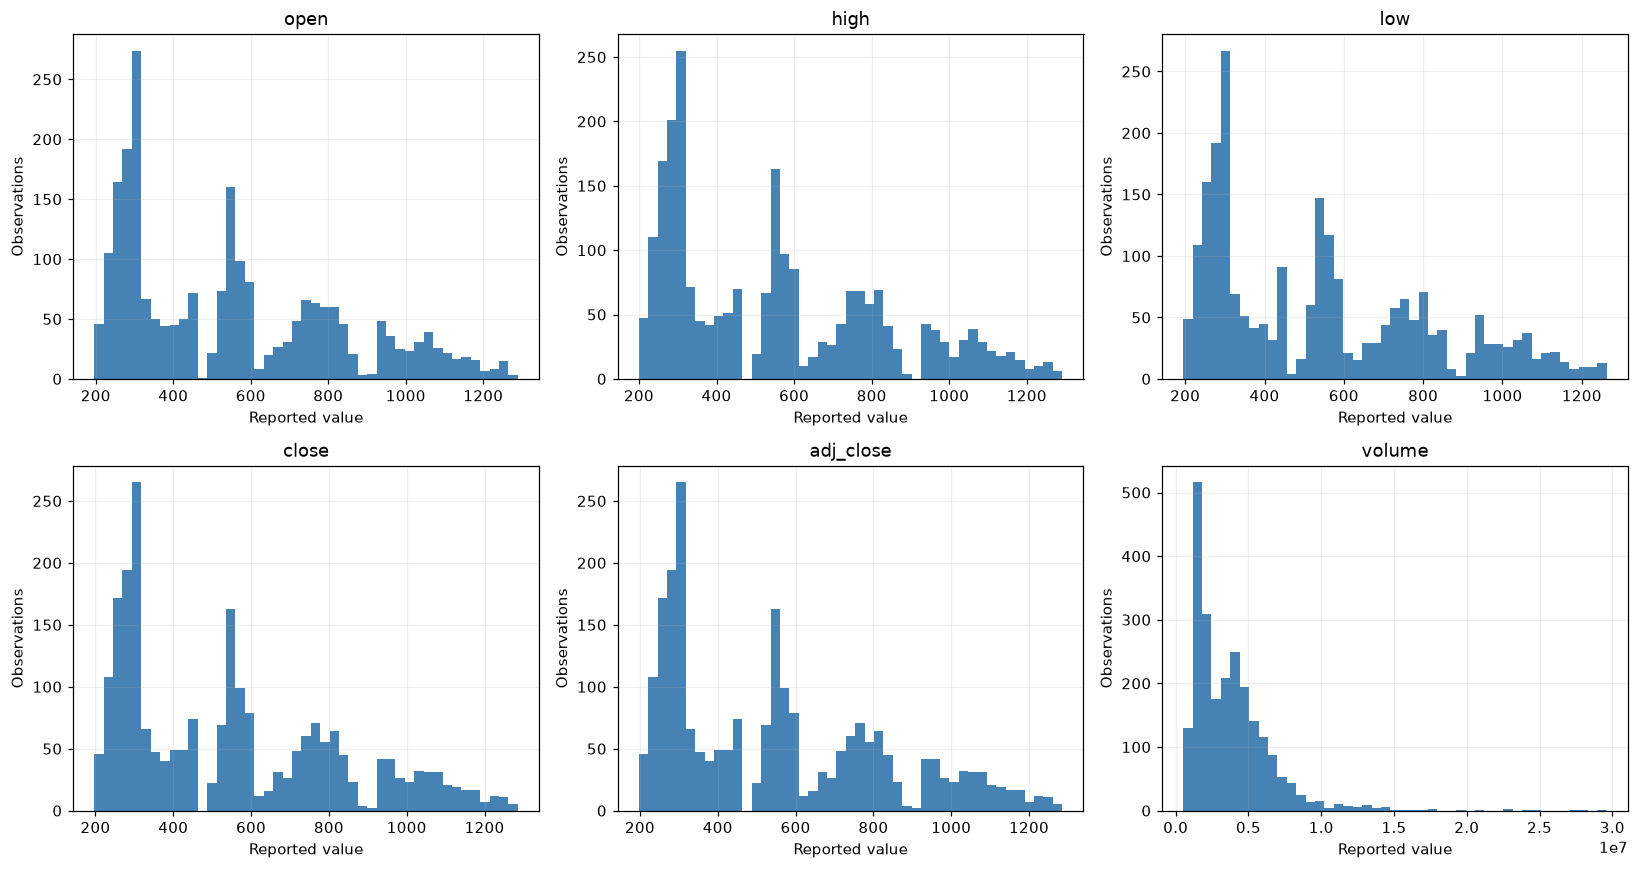

**Output interpretation.** Volume has median **3,250,200** and mean **3,764,886**. Differences between these describe asymmetry. Large spreads in price levels may reflect the long-term path rather than unusual daily shocks; returns are examined separately.

In [5]:
# Inspect robust summaries alongside means because levels and volume can be skewed.
summary = df.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
summary['IQR'] = summary['75%'] - summary['25%']
summary['skew'] = df.skew(); summary['excess_kurtosis'] = df.kurt()
display(summary)
fig, ax = plt.subplots(2,3,figsize=(15,8))
for a,c in zip(ax.flat,df.columns):
 a.hist(df[c],bins=45,color='steelblue'); a.set(title=c,xlabel='Reported value',ylabel='Observations')
finish()
explain(f'Volume has median **{df.volume.median():,.0f}** and mean **{df.volume.mean():,.0f}**. Differences between these describe asymmetry. Large spreads in price levels may reflect the long-term path rather than unusual daily shocks; returns are examined separately.')

## 6. Price path and adjustment consistency

Close and Adj Close are compared before choosing a return series.

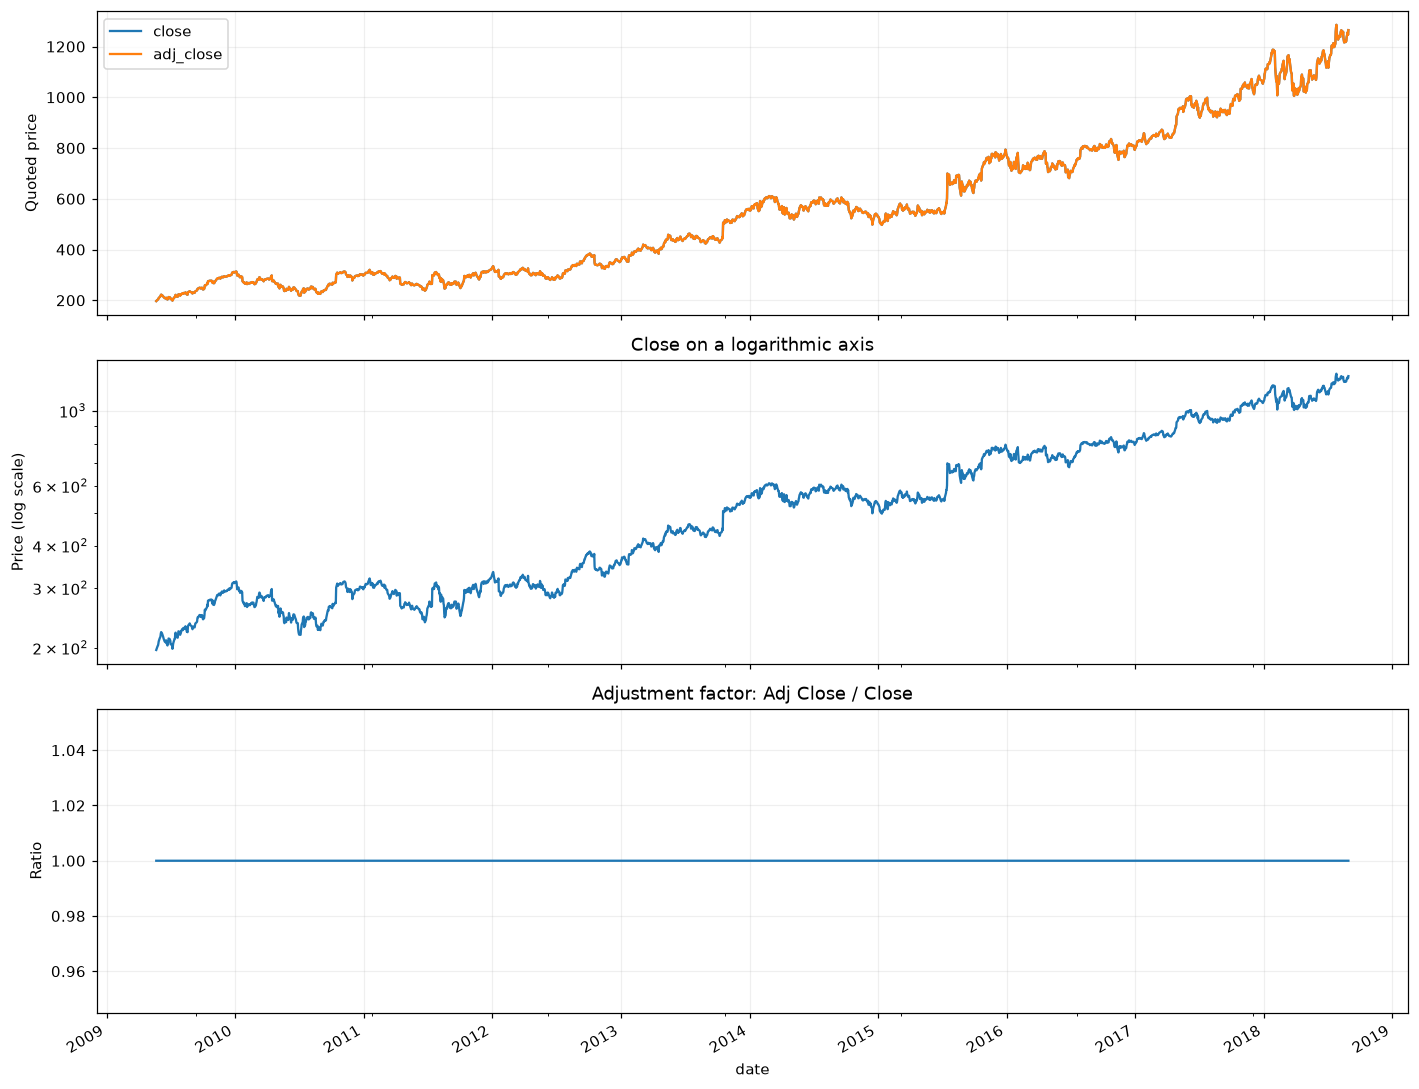

Max absolute Close–Adj Close difference: 0.0
Adjustment-factor jumps > 0.1%: 0


**Output interpretation.** Adj Close and Close are numerically identical: **True**. Their factor ranges from **1.000000** to **1.000000**. We analyze supplied adjusted-close returns, while retaining raw-close comparisons and avoiding a claim that this is a verified total-return series.

In [6]:
# Check adjustment equivalence before interpreting adjusted returns.
factor = df.adj_close / df.close
fig, ax = plt.subplots(3,1,figsize=(13,10),sharex=True)
df[['close','adj_close']].plot(ax=ax[0]); ax[0].set_ylabel('Quoted price')
df.close.plot(ax=ax[1],logy=True,title='Close on a logarithmic axis'); ax[1].set_ylabel('Price (log scale)')
factor.plot(ax=ax[2],title='Adjustment factor: Adj Close / Close'); ax[2].set_ylabel('Ratio')
finish()
print('Max absolute Close–Adj Close difference:', (df.close-df.adj_close).abs().max())
print('Adjustment-factor jumps > 0.1%:', (factor.pct_change(fill_method=None).abs()>.001).sum())
explain(f'Adj Close and Close are numerically identical: **{np.allclose(df.close,df.adj_close)}**. Their factor ranges from **{factor.min():.6f}** to **{factor.max():.6f}**. We analyze supplied adjusted-close returns, while retaining raw-close comparisons and avoiding a claim that this is a verified total-return series.')

## 7. Engineer interpretable daily features

Simple return is P(t)/P(t−1)−1; log return is log(P(t)/P(t−1)). The first return is undefined. Intraday and overnight returns use unadjusted OHLC consistently. Features computed using a session’s close or final volume become available only after that session.

In [7]:
# Use lagged denominators and preserve the first undefined return.
x = df.copy()
x['return'] = df.adj_close.pct_change(fill_method=None)
x['raw_return'] = df.close.pct_change(fill_method=None)
x['log_return'] = np.log(df.adj_close).diff()
x['overnight'] = df.open / df.close.shift(1)-1
x['intraday'] = df.close / df.open-1
x['range_pct'] = (df.high-df.low)/df.close
x['log_volume'] = np.log1p(df.volume)
x['volume_change'] = df.volume.pct_change(fill_method=None)
x['abs_return'] = x['return'].abs()
r = x['return'].dropna()
identity_error = ((1+x.overnight)*(1+x.intraday)-1-x.raw_return).abs().max()
assert identity_error < 1e-10
assert np.allclose(np.expm1(x.log_return.dropna()),r)
display(x[['return','log_return','overnight','intraday','range_pct','volume_change']].head(8))
explain(f'There are **{len(r):,} valid daily returns**. The overnight/intraday multiplicative identity agrees with raw close returns within **{identity_error:.2g}**. Initial missing values arise from unavailable history and are not filled with invented zero returns.')

,return,log_return,overnight,intraday,range_pct,volume_change
date,,,,,,
2009-05-22,NaN,NaN,NaN,-0.00797,0.01690,NaN
2009-05-26,0.02760,0.02722,-0.00394,0.03166,0.03710,0.80642
2009-05-27,0.00297,0.00296,0.00317,-0.00020,0.01738,-0.02260
2009-05-28,0.01193,0.01186,0.00769,0.00421,0.01708,-0.12046
2009-05-29,0.01664,0.01651,0.00417,0.01242,0.01565,-0.00771
2009-06-01,0.02236,0.02212,0.00360,0.01870,0.02595,0.25458
2009-06-02,0.00431,0.00430,-0.00073,0.00504,0.01531,-0.21033
2009-06-03,0.00759,0.00756,-0.00560,0.01326,0.01960,0.34655


**Output interpretation.** There are **2,334 valid daily returns**. The overnight/intraday multiplicative identity agrees with raw close returns within **2.2e-16**. Initial missing values arise from unavailable history and are not filled with invented zero returns.

## 8. Return distribution, normality and tail observations

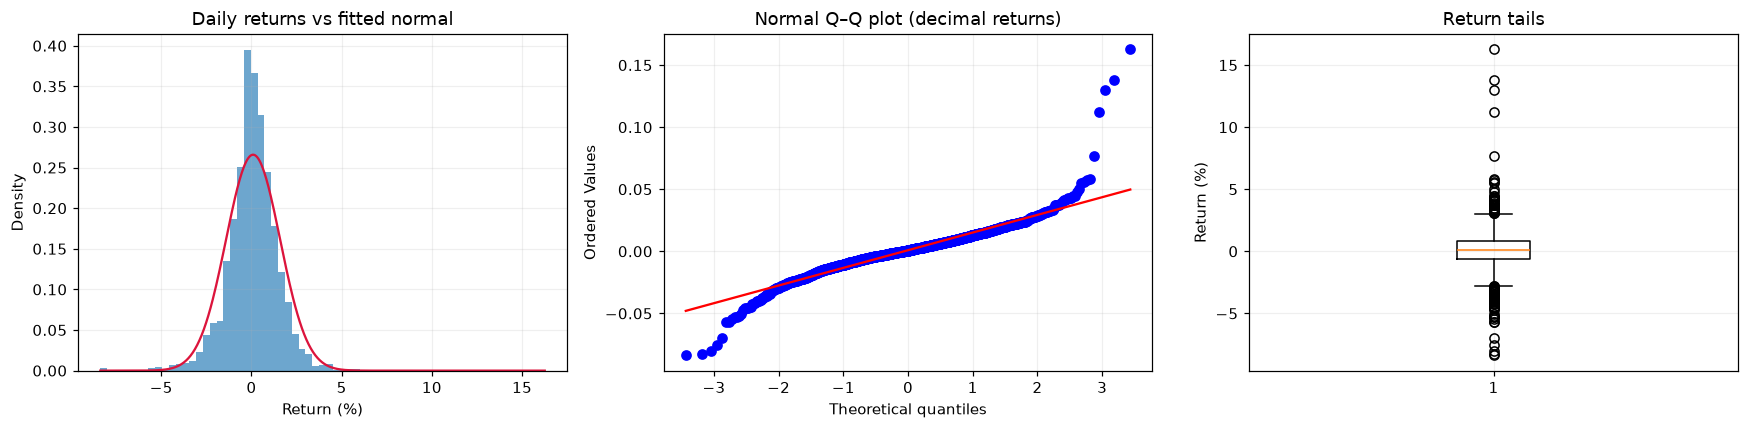

,Value
mean_pct,0.09087
median_pct,0.06807
std_pct,1.50055
skew,0.90675
excess_kurtosis,14.47203
positive_pct,52.57069
zero_pct,0.08569
JB_statistic,"20,593.08593"
JB_pvalue,0.00000


**Output interpretation.** Daily mean and median returns are **0.091%** and **0.068%**. Excess kurtosis is **14.47** (normal reference: 0), and the Jarque–Bera p-value is **0**. Treat extreme days as observations requiring investigation, not errors to remove automatically.

In [8]:
# Compare empirical tails with a normal reference rather than assuming normality.
fig, ax = plt.subplots(1,3,figsize=(16,4))
ax[0].hist(r*100,bins=65,density=True,alpha=.65)
grid=np.linspace(r.min()*100,r.max()*100,400)
ax[0].plot(grid,stats.norm.pdf(grid,r.mean()*100,r.std()*100),color='crimson')
ax[0].set(title='Daily returns vs fitted normal',xlabel='Return (%)',ylabel='Density')
stats.probplot(r,dist='norm',plot=ax[1]); ax[1].set_title('Normal Q–Q plot (decimal returns)')
ax[2].boxplot(r*100); ax[2].set(title='Return tails',ylabel='Return (%)')
finish()
jb=stats.jarque_bera(r)
display(pd.Series({'mean_pct':r.mean()*100,'median_pct':r.median()*100,'std_pct':r.std()*100,'skew':r.skew(),'excess_kurtosis':r.kurt(),'positive_pct':r.gt(0).mean()*100,'zero_pct':r.eq(0).mean()*100,'JB_statistic':jb.statistic,'JB_pvalue':jb.pvalue}).to_frame('Value'))
explain(f'Daily mean and median returns are **{r.mean():.3%}** and **{r.median():.3%}**. Excess kurtosis is **{r.kurt():.2f}** (normal reference: 0), and the Jarque–Bera p-value is **{jb.pvalue:.3g}**. Treat extreme days as observations requiring investigation, not errors to remove automatically.')

## 9. Outlier audit and sensitivity to extreme days

In [9]:
# Keep outliers in the main analysis; clipping is only a sensitivity check.
q1,q3=r.quantile([.25,.75]); iqr=q3-q1
mad=(r-r.median()).abs().median()
flags=pd.DataFrame({'IQR':(r<q1-1.5*iqr)|(r>q3+1.5*iqr),'robust_z_gt_3_5':(.67449*(r-r.median())/mad).abs()>3.5})
display(flags.sum().to_frame('Count'))
extreme_dates=r.abs().nlargest(12).index
display(x.loc[extreme_dates,['close','adj_close','return','overnight','intraday','volume','range_pct']])
lo,hi=r.quantile([.01,.99]); clipped=r.clip(lo,hi)
display(pd.DataFrame({'original':r.agg(['mean','std','skew','kurt']), 'winsorized_1_99':clipped.agg(['mean','std','skew','kurt'])}))
explain(f'The largest absolute daily return is **{r.loc[extreme_dates[0]]:.2%}** on **{extreme_dates[0].date()}**. Clipping the outer 1% on each side changes daily volatility from **{r.std():.3%}** to **{clipped.std():.3%}**. This measures tail sensitivity, not an improvement in data quality. Event causes are not inferred from the price table alone.')

,Count
IQR,103
robust_z_gt_3_5,51


,close,adj_close,return,overnight,intraday,volume,range_pct
date,,,,,,,
2015-07-17,699.62000,699.62000,0.16258,0.12998,0.02885,12858100,0.03573
2013-10-18,506.21121,506.21121,0.13796,0.09877,0.03567,23109600,0.04099
2011-07-15,299.10910,299.10910,0.12984,0.12962,0.00020,27436700,0.02023
2010-10-15,301.02603,301.02603,0.11188,0.10785,0.00364,29619900,0.01669
2012-01-20,293.28830,293.28830,-0.08377,-0.07668,-0.00769,21131400,0.01587
2011-04-15,265.61560,265.61560,-0.08264,-0.05742,-0.02676,28059300,0.02956
2012-10-18,347.84784,347.84784,-0.08007,0.00007,-0.08013,24859900,0.12003
2015-08-26,659.73999,659.73999,0.07718,0.05001,0.02587,4387000,0.04867
2010-04-16,275.35034,275.35034,-0.07584,-0.05426,-0.02282,24446500,0.03486


,original,winsorized_1_99
mean,0.00091,0.00080
std,0.01501,0.01316
skew,0.90675,-0.19182
kurt,14.47203,0.97178


**Output interpretation.** The largest absolute daily return is **16.26%** on **2015-07-17**. Clipping the outer 1% on each side changes daily volatility from **1.501%** to **1.316%**. This measures tail sensitivity, not an improvement in data quality. Event causes are not inferred from the price table alone.

## 10. Historical tail risk and uncertainty in the mean

In [10]:
# Resample contiguous blocks to retain short-range dependence.
tails=[]
for alpha in [.01,.05]:
 q=r.quantile(alpha); tail=r[r<=q]
 tails.append({'tail_probability':alpha,'return_quantile':q,'loss_VaR':-q,'loss_expected_shortfall':-tail.mean(),'tail_observations':len(tail)})
display(pd.DataFrame(tails))
arr=r.to_numpy(); boot_rows=[]
for block in [5,10,21]:
 means=[]
 for _ in range(1500):
  starts=rng.integers(0,len(arr),size=int(np.ceil(len(arr)/block)))
  idx=((starts[:,None]+np.arange(block))%len(arr)).ravel()[:len(arr)]
  means.append(arr[idx].mean())
 ci=np.quantile(means,[.025,.975])
 boot_rows.append({'block_sessions':block,'mean':r.mean(),'CI_low':ci[0],'CI_high':ci[1]})
boot=pd.DataFrame(boot_rows); display(boot)
explain(f'The historical 5% return quantile is **{r.quantile(.05):.2%}**. The block-bootstrap intervals include zero for **{((boot.CI_low<=0)&(boot.CI_high>=0)).sum()} of {len(boot)}** block lengths. Tail estimates rely on few events, and resampling cannot reproduce unseen structural changes.')

,tail_probability,return_quantile,loss_VaR,loss_expected_shortfall,tail_observations
0,0.01000,-0.04025,0.04025,0.05378,24
1,0.05000,-0.02223,0.02223,0.03301,117


,block_sessions,mean,CI_low,CI_high
0,5,0.00091,0.00025,0.00154
1,10,0.00091,0.00030,0.00148
2,21,0.00091,0.00032,0.00150


**Output interpretation.** The historical 5% return quantile is **-2.22%**. The block-bootstrap intervals include zero for **0 of 3** block lengths. Tail estimates rely on few events, and resampling cannot reproduce unseen structural changes.

## 11. Growth, drawdowns and recovery episodes

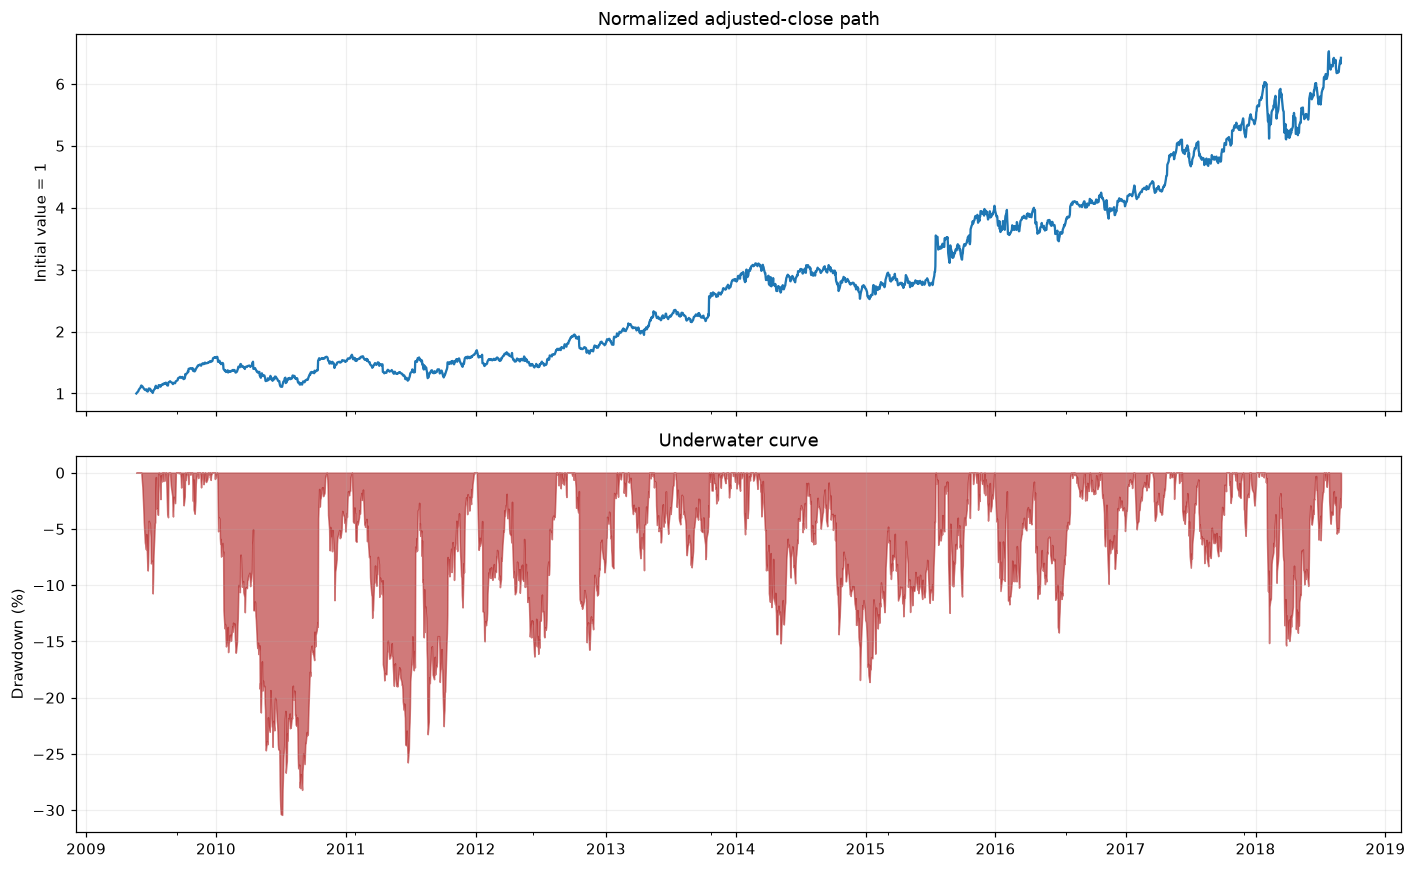

,peak,trough,recovery,depth,sessions_since_peak,recovered
21,2010-01-04,2010-07-06,2010-11-08,-0.30424,214,True
23,2011-01-18,2011-06-24,2011-12-27,-0.25757,238,True
60,2014-02-26,2015-01-12,2015-07-17,-0.18608,350,True
25,2012-01-04,2012-06-14,2012-08-14,-0.16345,154,True
35,2012-10-04,2012-11-16,2013-02-01,-0.15737,80,True
92,2018-01-26,2018-03-28,2018-07-12,-0.15358,115,True
68,2015-12-29,2016-06-27,2016-08-01,-0.14210,148,True
61,2015-07-17,2015-08-25,2015-10-19,-0.12457,65,True
22,2010-11-08,2010-11-30,2011-01-18,-0.11337,48,True
0,2009-06-05,2009-07-07,2009-07-24,-0.10733,34,True


**Output interpretation.** The supplied adjusted-close path grew **6.42×**, corresponding to **22.21%** annualized calendar-time growth. Maximum drawdown was **-30.42%** on **2010-07-06**. Fees, slippage and independent verification of distributions are absent; terminal growth alone conceals substantial interim risk.

In [11]:
# Track recovery episodes separately from the terminal wealth multiple.
wealth=df.adj_close/df.adj_close.iloc[0]
drawdown=wealth/wealth.cummax()-1
fig,ax=plt.subplots(2,1,figsize=(13,8),sharex=True)
wealth.plot(ax=ax[0],title='Normalized adjusted-close path'); ax[0].set_ylabel('Initial value = 1')
ax[1].fill_between(df.index,drawdown*100,0,color='firebrick',alpha=.6); ax[1].set(title='Underwater curve',ylabel='Drawdown (%)')
finish()
episodes=[]; peak=0; start=None
for i,d in enumerate(drawdown):
 if d>=-1e-12:
  if start is not None:
   trough=start+np.argmin(drawdown.iloc[start:i+1].to_numpy())
   episodes.append([df.index[peak],df.index[trough],df.index[i],drawdown.iloc[trough],i-peak,True]); start=None
  peak=i
 elif start is None: start=i
if start is not None:
 trough=start+np.argmin(drawdown.iloc[start:].to_numpy())
 episodes.append([df.index[peak],df.index[trough],pd.NaT,drawdown.iloc[trough],len(df)-1-peak,False])
dd_table=pd.DataFrame(episodes,columns=['peak','trough','recovery','depth','sessions_since_peak','recovered'])
display(dd_table.sort_values('depth').head(10))
years=(df.index[-1]-df.index[0]).days/365.25
cagr=wealth.iloc[-1]**(1/years)-1
explain(f'The supplied adjusted-close path grew **{wealth.iloc[-1]:.2f}×**, corresponding to **{cagr:.2%}** annualized calendar-time growth. Maximum drawdown was **{drawdown.min():.2%}** on **{drawdown.idxmin().date()}**. Fees, slippage and independent verification of distributions are absent; terminal growth alone conceals substantial interim risk.')

## 12. Rolling volatility and changing market conditions


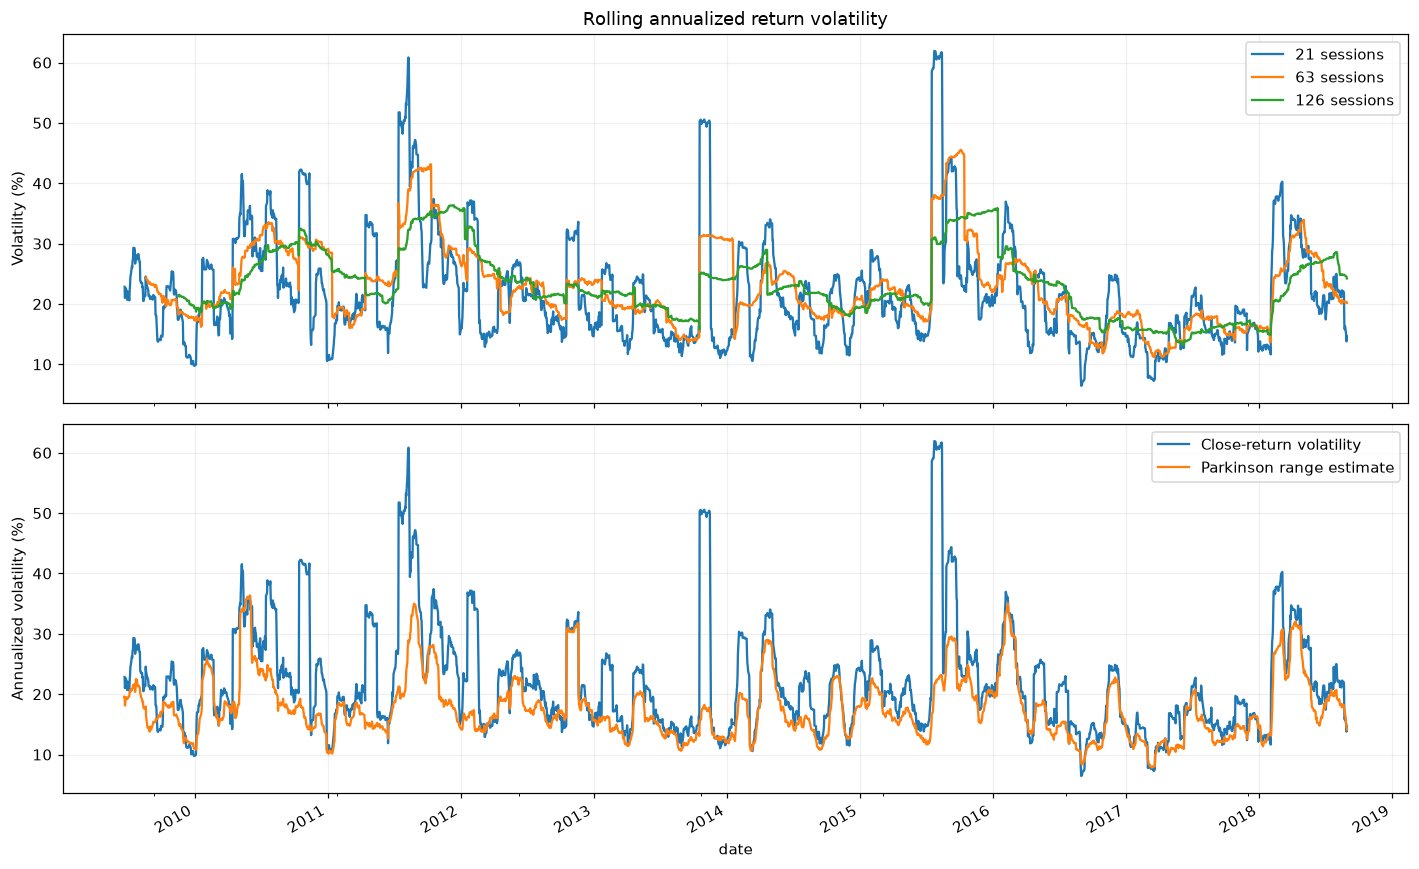

,count,mean,std,min,25%,50%,75%,max
21 sessions,"2,314.00000",0.22076,0.09140,0.06453,0.15483,0.20353,0.25497,0.61933
63 sessions,"2,272.00000",0.22955,0.06730,0.11251,0.18287,0.21483,0.26701,0.45547
126 sessions,"2,209.00000",0.23300,0.05529,0.13189,0.19577,0.22066,0.26475,0.36328


**Output interpretation.** 21-session annualized volatility ranges from **6.45%** to **61.93%**, peaking on **2015-07-24**. This range motivates testing stability across chronological periods. Rolling estimates overlap and therefore are not independent observations.

In [12]:
# Require full rolling windows to avoid misleading warm-up estimates.
vol=pd.DataFrame({f'{w} sessions':r.rolling(w,min_periods=w).std()*np.sqrt(252) for w in [21,63,126]})
parkinson=np.sqrt((np.log(df.high/df.low)**2).rolling(21).mean()*252/(4*np.log(2)))
fig,ax=plt.subplots(2,1,figsize=(13,8),sharex=True)
(vol*100).plot(ax=ax[0]); ax[0].set(title='Rolling annualized return volatility',ylabel='Volatility (%)')
(vol['21 sessions']*100).plot(ax=ax[1],label='Close-return volatility')
(parkinson*100).plot(ax=ax[1],label='Parkinson range estimate'); ax[1].legend(); ax[1].set_ylabel('Annualized volatility (%)')
finish()
display(vol.describe().T)
explain(f'21-session annualized volatility ranges from **{vol["21 sessions"].min():.2%}** to **{vol["21 sessions"].max():.2%}**, peaking on **{vol["21 sessions"].idxmax().date()}**. This range motivates testing stability across chronological periods. Rolling estimates overlap and therefore are not independent observations.')

## 13. Serial dependence and volatility clustering

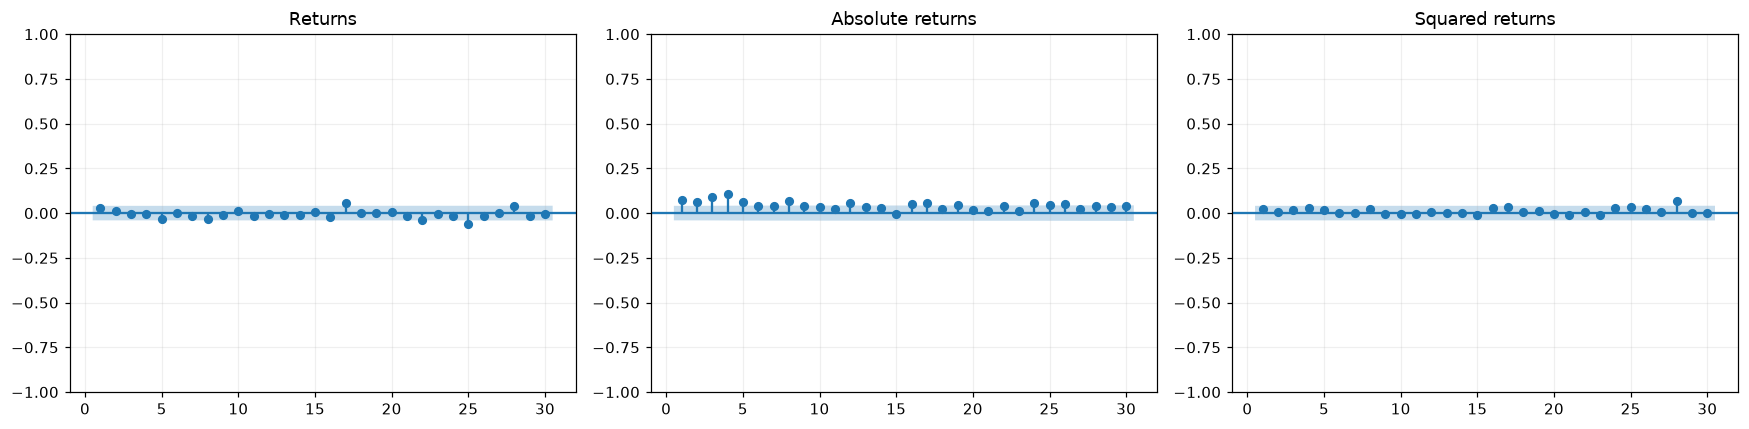

lb_stat  lb_pvalue
series         lag                     
return         5     5.30950    0.37929
               10    9.33318    0.50080
               20   19.73841    0.47440
abs_return     5    74.90691    0.00000
               10   99.45574    0.00000
               20  133.05404    0.00000
squared_return 5     5.10933    0.40268
               10    6.22540    0.79598
               20   11.52192    0.93155

**Output interpretation.** Lag-one autocorrelation is **0.030** for returns and **0.073** for absolute returns. Compare the three panels: persistence in magnitude can exist even when direction is weakly related. Confidence bands are approximate and testing many lags increases false discoveries.

In [13]:
# Separate directional dependence from persistence in return magnitude.
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,s,title in zip(ax,[r,r.abs(),r**2],['Returns','Absolute returns','Squared returns']):
 plot_acf(s,lags=30,zero=False,ax=a); a.set_title(title)
finish()
lb=pd.concat({name:acorr_ljungbox(s,lags=[5,10,20],return_df=True) for name,s in [('return',r),('abs_return',r.abs()),('squared_return',r**2)]},names=['series','lag'])
display(lb)
explain(f'Lag-one autocorrelation is **{r.autocorr(1):.3f}** for returns and **{r.abs().autocorr(1):.3f}** for absolute returns. Compare the three panels: persistence in magnitude can exist even when direction is weakly related. Confidence bands are approximate and testing many lags increases false discoveries.')

## 14. Stationarity diagnostics

In [14]:
# Use both tests because their null hypotheses are different.
import warnings
station=[]
for name,s,reg in [('log_price',np.log(df.adj_close),'ct'),('return',r,'c')]:
 a=adfuller(s,regression=reg,autolag='AIC')
 with warnings.catch_warnings(record=True) as caught:
  warnings.simplefilter('always'); k=kpss(s,regression=reg,nlags='auto')
 station.append({'series':name,'deterministic_terms':reg,'ADF_stat':a[0],'ADF_p':a[1],'ADF_lags':a[2],'KPSS_stat':k[0],'KPSS_p':k[1],'KPSS_lags':k[2],'KPSS_note':' | '.join(str(w.message) for w in caught)})
station=pd.DataFrame(station); display(station)
explain('Read each p-value against its own null: ADF p < 0.05 rejects a unit root, whereas KPSS p < 0.05 rejects the specified form of stationarity. Neither passing a return test nor differencing establishes independent, identically distributed observations; volatility and regime shifts still matter.')

/var/folders/72/j1gt86rn4dg7jtw_px_7nq_w0000gn/T/ipykernel_29291/877187297.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,regression=reg,autolag='AIC')
/var/folders/72/j1gt86rn4dg7jtw_px_7nq_w0000gn/T/ipykernel_29291/877187297.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,regression=reg,autolag='AIC')


,series,deterministic_terms,ADF_stat,ADF_p,ADF_lags,KPSS_stat,KPSS_p,KPSS_lags,KPSS_note
0,log_price,ct,-3.61768,0.02838,1,0.44496,0.01000,29,The test statistic is outside of the range of ...
1,return,c,-46.88716,0.00000,0,0.02118,0.10000,6,The test statistic is outside of the range of ...


**Output interpretation.** Read each p-value against its own null: ADF p < 0.05 rejects a unit root, whereas KPSS p < 0.05 rejects the specified form of stationarity. Neither passing a return test nor differencing establishes independent, identically distributed observations; volatility and regime shifts still matter.

## 15. Volume, liquidity proxies and price–volume relationships


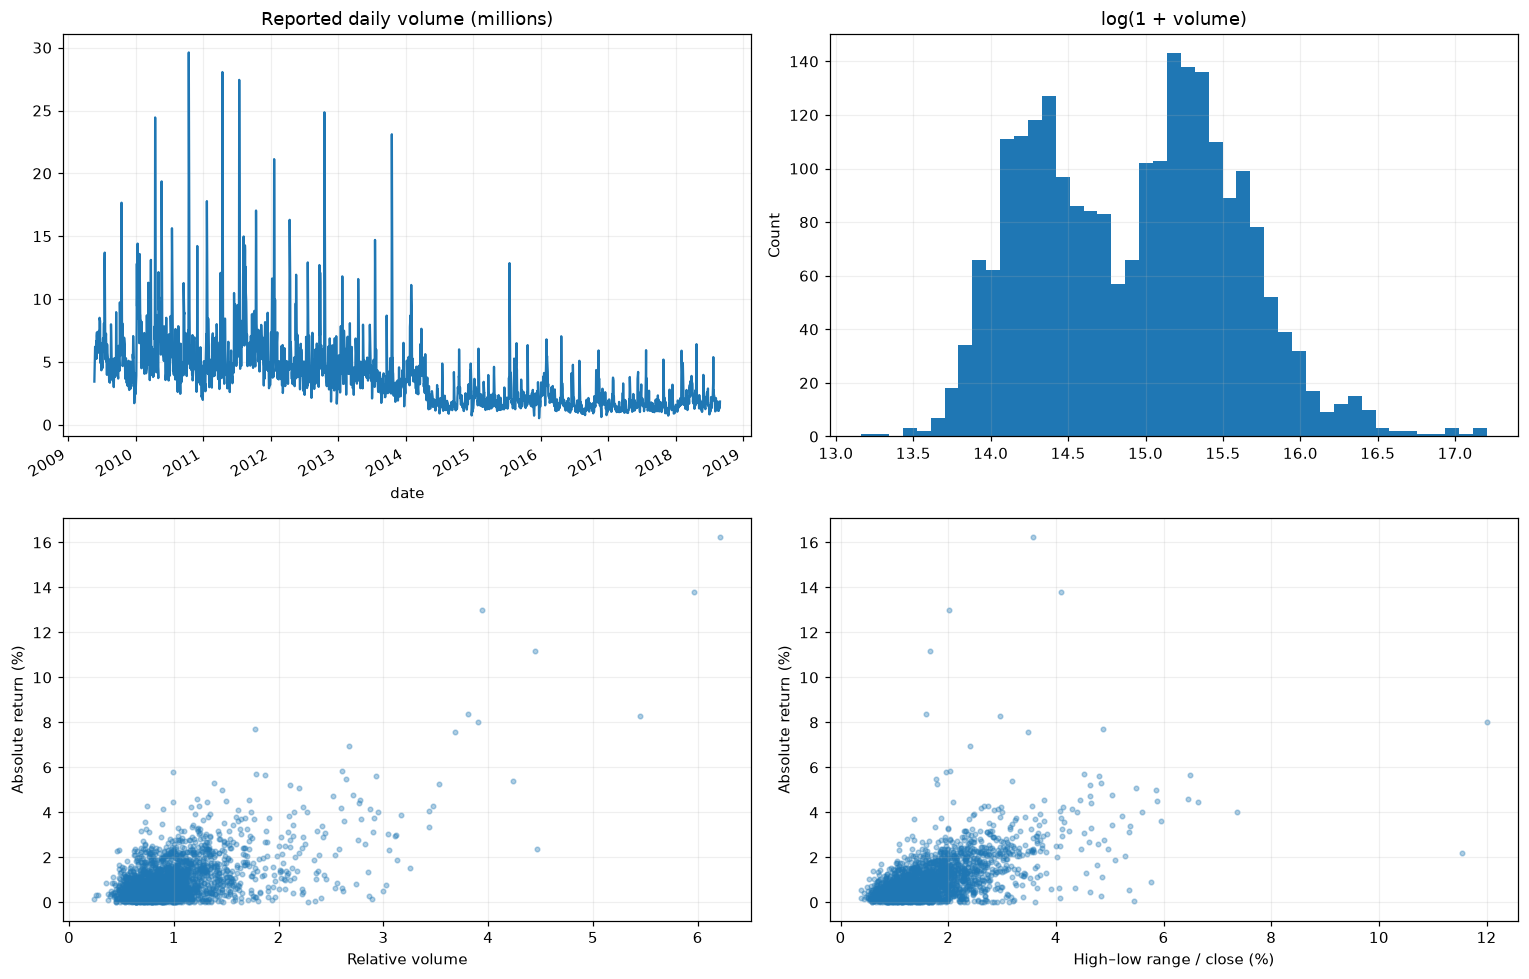

,return,abs_return,range_pct,log_volume,relative_volume,volume_change
return,1.00000,0.09946,-0.05095,0.00293,0.01114,0.00286
abs_return,0.09946,1.00000,0.55545,0.30958,0.39678,0.34247
range_pct,-0.05095,0.55545,1.00000,0.44091,0.44195,0.25178
log_volume,0.00293,0.30958,0.44091,1.00000,0.43527,0.23066
relative_volume,0.01114,0.39678,0.44195,0.43527,1.00000,0.45744
volume_change,0.00286,0.34247,0.25178,0.23066,0.45744,1.00000


,n,mean_return,mean_abs_return
relative_volume,,,
"(0.24, 0.726]",579,0.00076,0.00617
"(0.726, 0.904]",579,0.00034,0.00732
"(0.904, 1.142]",578,0.00255,0.00990
"(1.142, 6.213]",579,-0.00010,0.01758


**Output interpretation.** Spearman correlation between relative volume and absolute return is **0.397**. This measures co-movement in ranks, not causality or a signal known before the close. Volume comparability can also depend on the vendor’s split-adjustment conventions.

In [15]:
# Lag the rolling volume baseline so it uses preceding sessions only.
x['relative_volume']=df.volume/df.volume.shift(1).rolling(20).mean()
fig,ax=plt.subplots(2,2,figsize=(14,9))
(df.volume/1e6).plot(ax=ax[0,0],title='Reported daily volume (millions)')
ax[0,1].hist(x.log_volume,bins=45); ax[0,1].set(title='log(1 + volume)',ylabel='Count')
ax[1,0].scatter(x.relative_volume,x.abs_return*100,s=9,alpha=.35); ax[1,0].set(xlabel='Relative volume',ylabel='Absolute return (%)')
ax[1,1].scatter(x.range_pct*100,x.abs_return*100,s=9,alpha=.35); ax[1,1].set(xlabel='High–low range / close (%)',ylabel='Absolute return (%)')
finish()
cols=['return','abs_return','range_pct','log_volume','relative_volume','volume_change']
display(x[cols].corr(method='spearman'))
q=pd.qcut(x.relative_volume,4,duplicates='drop')
display(x.groupby(q,observed=True).agg(n=('return','count'),mean_return=('return','mean'),mean_abs_return=('abs_return','mean')))
explain(f'Spearman correlation between relative volume and absolute return is **{x.relative_volume.corr(x.abs_return,method="spearman"):.3f}**. This measures co-movement in ranks, not causality or a signal known before the close. Volume comparability can also depend on the vendor’s split-adjustment conventions.')

## 16. Overnight versus intraday behavior

,count,mean,median,std,min,max,skew,kurt
overnight,"2,334.00000",0.00101,0.00094,0.00966,-0.07668,0.12998,3.37320,49.76981
intraday,"2,334.00000",-0.00010,0.00004,0.01132,-0.08013,0.04879,-0.47179,2.78627
raw_return,"2,334.00000",0.00091,0.00068,0.01501,-0.08377,0.16258,0.90675,14.47203


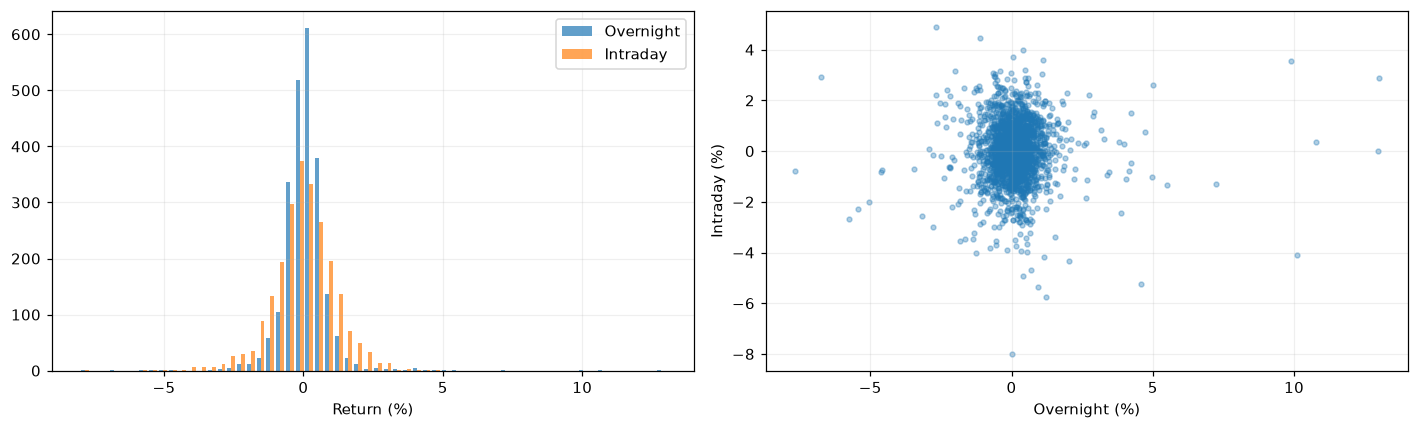

**Output interpretation.** Overnight standard deviation is **0.97%**, versus **1.13%** intraday. Their correlation is **0.015**. The split describes sampled price movement and says nothing by itself about fill quality at opens or closes.

In [16]:
# Compare components on the same complete set of sessions.
parts=x[['overnight','intraday','raw_return']].dropna()
display(parts.agg(['count','mean','median','std','min','max','skew','kurt']).T)
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].hist([parts.overnight*100,parts.intraday*100],bins=60,label=['Overnight','Intraday'],alpha=.7); ax[0].legend(); ax[0].set_xlabel('Return (%)')
ax[1].scatter(parts.overnight*100,parts.intraday*100,s=10,alpha=.35); ax[1].set(xlabel='Overnight (%)',ylabel='Intraday (%)'); finish()
explain(f'Overnight standard deviation is **{parts.overnight.std():.2%}**, versus **{parts.intraday.std():.2%}** intraday. Their correlation is **{parts.overnight.corr(parts.intraday):.3f}**. The split describes sampled price movement and says nothing by itself about fill quality at opens or closes.')

## 17. Calendar aggregation and seasonality

,count,mean,median,std
weekday,,,,
Monday,437,0.00097,0.00069,0.01377
Tuesday,480,0.00121,0.00108,0.01348
Wednesday,480,0.00161,0.00105,0.01216
Thursday,471,0.00039,0.00068,0.01323
Friday,466,0.00034,-0.00033,0.02084


,count,mean,median,std
month,,,,
1,181,0.00017,0.00020,0.01665
2,173,0.00075,0.00207,0.01347
3,197,-0.00013,0.00019,0.01257
4,186,-0.00110,-0.00009,0.01687
5,195,0.00124,0.00167,0.01352
6,215,-0.00082,-0.00174,0.01289
7,211,0.00406,0.00266,0.02032
8,220,-0.00026,-0.00105,0.01522
9,185,0.00191,0.00107,0.01162


,n,mean,volatility,compounded_return,annualized_volatility
year,,,,,
2009,154,0.00304,0.01261,0.57555,0.20022
2010,252,-0.00002,0.01756,-0.04195,0.27874
2011,252,0.00050,0.01858,0.08743,0.29491
2012,250,0.00047,0.01443,0.09518,0.22904
2013,252,0.00192,0.01381,0.58431,0.21916
2014,252,-0.00013,0.01341,-0.05394,0.21283
2015,252,0.00168,0.01818,0.46612,0.28856
2016,252,0.00015,0.01267,0.01856,0.20121
2017,251,0.00118,0.00963,0.32930,0.15286


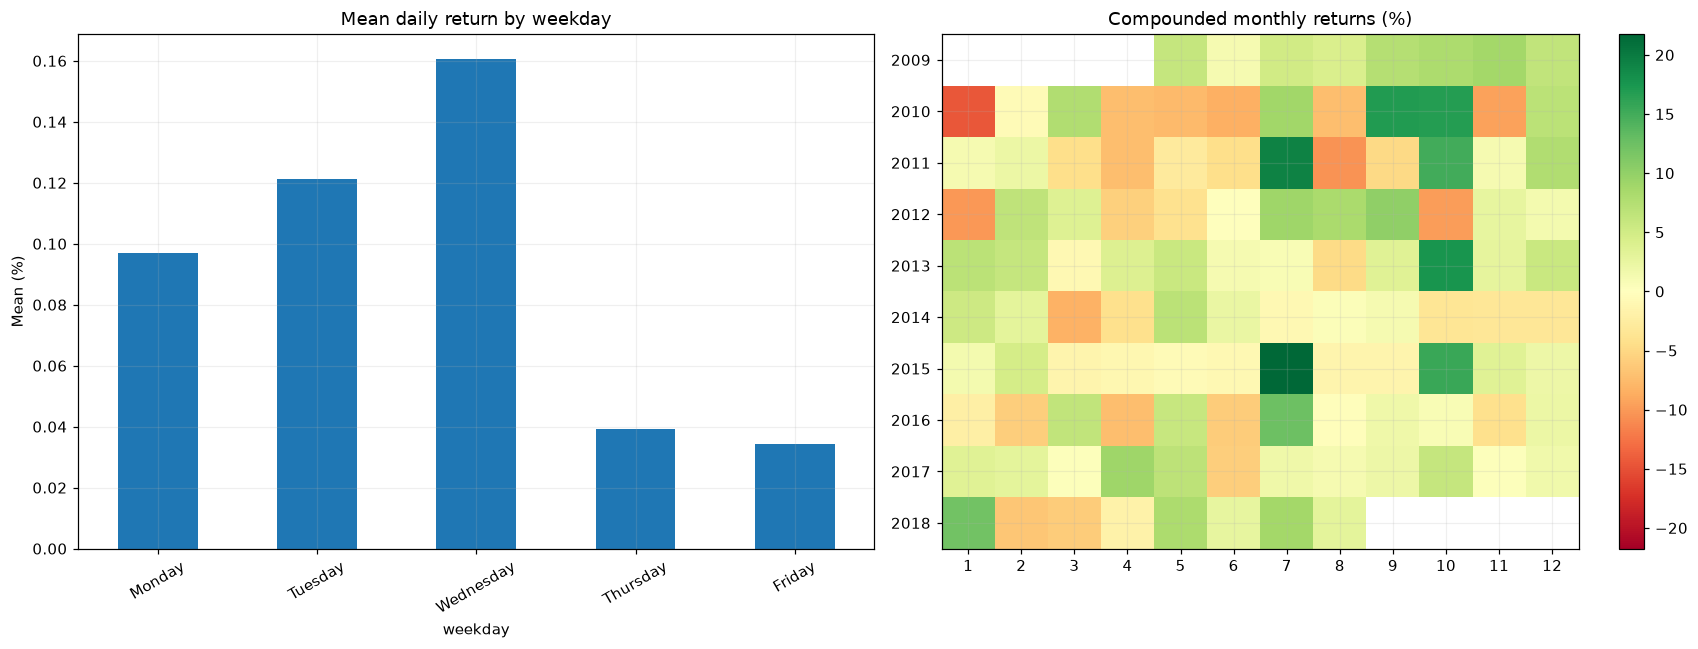

**Output interpretation.** The largest observed weekday mean occurs on **Wednesday**. This is a retrospective ranking across five groups, not a tested edge. Monthly returns range from **-14.52%** to **21.75%**. The sample starts 2009-05-22 and ends 2018-08-29, so boundary periods are not assumed complete.

In [17]:
# Compound returns within calendar periods rather than summing them.
cal=r.to_frame('return'); cal['weekday']=cal.index.day_name(); cal['month']=cal.index.month; cal['year']=cal.index.year
weekday=cal.groupby('weekday')['return'].agg(['count','mean','median','std']).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday'])
monthstats=cal.groupby('month')['return'].agg(['count','mean','median','std'])
monthly=r.groupby(r.index.to_period('M')).apply(lambda s:(1+s).prod()-1)
annual=cal.groupby('year')['return'].agg(n='count',mean='mean',volatility='std')
annual['compounded_return']=r.groupby(r.index.year).apply(lambda s:(1+s).prod()-1)
annual['annualized_volatility']=annual.volatility*np.sqrt(252)
display(weekday); display(monthstats); display(annual)
heat=monthly.to_frame('return'); heat['year']=heat.index.year; heat['month']=heat.index.month
pivot=heat.pivot(index='year',columns='month',values='return').reindex(columns=range(1,13))
fig,ax=plt.subplots(1,2,figsize=(16,6))
(weekday['mean']*100).plot.bar(ax=ax[0],title='Mean daily return by weekday',rot=30); ax[0].set_ylabel('Mean (%)')
limit=np.nanmax(np.abs(pivot.to_numpy()))*100
im=ax[1].imshow(pivot*100,cmap='RdYlGn',aspect='auto',vmin=-limit,vmax=limit)
ax[1].set(xticks=range(12),xticklabels=range(1,13),yticks=range(len(pivot)),yticklabels=pivot.index,title='Compounded monthly returns (%)')
fig.colorbar(im,ax=ax[1]); finish()
explain(f'The largest observed weekday mean occurs on **{weekday["mean"].idxmax()}**. This is a retrospective ranking across five groups, not a tested edge. Monthly returns range from **{monthly.min():.2%}** to **{monthly.max():.2%}**. The sample starts {df.index[0].date()} and ends {df.index[-1].date()}, so boundary periods are not assumed complete.')

## 18. Correlation: price levels versus transformed features

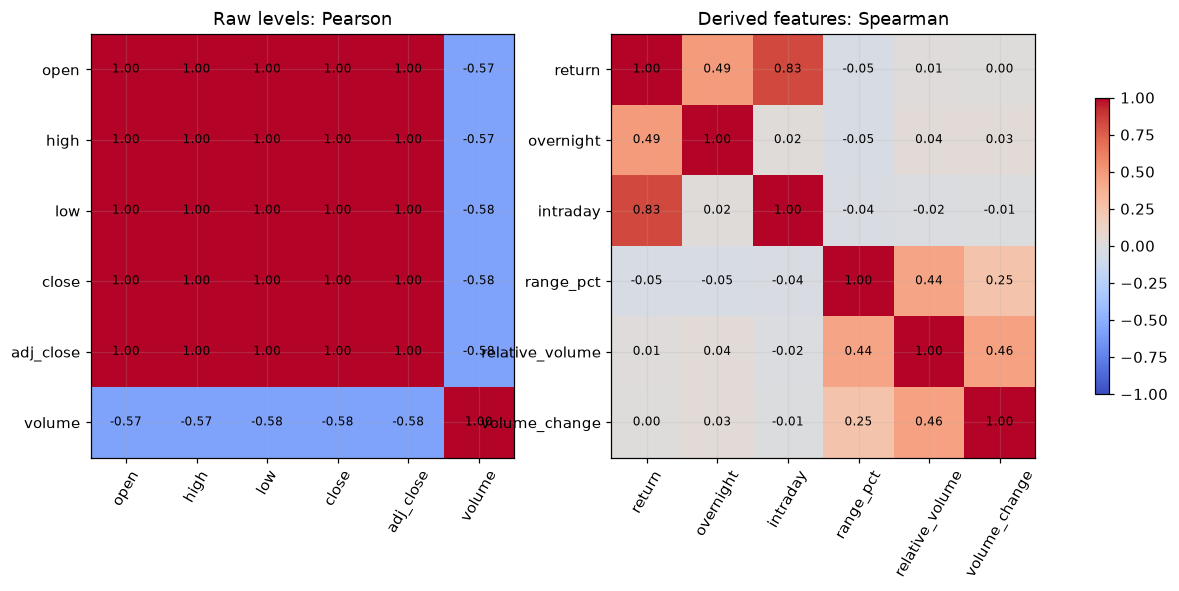

**Output interpretation.** High OHLC correlations are expected because all four describe the same session’s price level. They do not establish predictive value. Same-day intraday/overnight components also share a mathematical relationship with the daily return, so their correlation is partly structural.

In [18]:
# Compare levels and transformed features to expose mechanical correlations.
fig,ax=plt.subplots(1,2,figsize=(14,5))
for a,c,title in [(ax[0],df.corr(),'Raw levels: Pearson'),(ax[1],x[['return','overnight','intraday','range_pct','relative_volume','volume_change']].corr(method='spearman'),'Derived features: Spearman')]:
 im=a.imshow(c,vmin=-1,vmax=1,cmap='coolwarm'); a.set(xticks=range(len(c)),yticks=range(len(c)),xticklabels=c.columns,yticklabels=c.columns,title=title); a.tick_params(axis='x',rotation=60)
 for i in range(len(c)):
  for j in range(len(c)): a.text(j,i,f'{c.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax.ravel().tolist(),shrink=.7); plt.show(); plt.close('all')
explain('High OHLC correlations are expected because all four describe the same session’s price level. They do not establish predictive value. Same-day intraday/overnight components also share a mathematical relationship with the daily return, so their correlation is partly structural.')

## 19. Technical indicators and warm-up effects

,count,min,median,max
trend_gap,"2,286.00000",-0.07015,0.01073,0.11921
macd_pct,"2,310.00000",-0.03702,0.00508,0.05277
bb_width,"2,316.00000",0.02488,0.08376,0.41241
rsi,"2,321.00000",22.27757,54.47401,88.64022
momentum5,"2,330.00000",-0.14716,0.00512,0.25806
relative_volume,"2,315.00000",0.24126,0.90358,6.21275
range_pct,"2,335.00000",0.00382,0.01512,0.12003


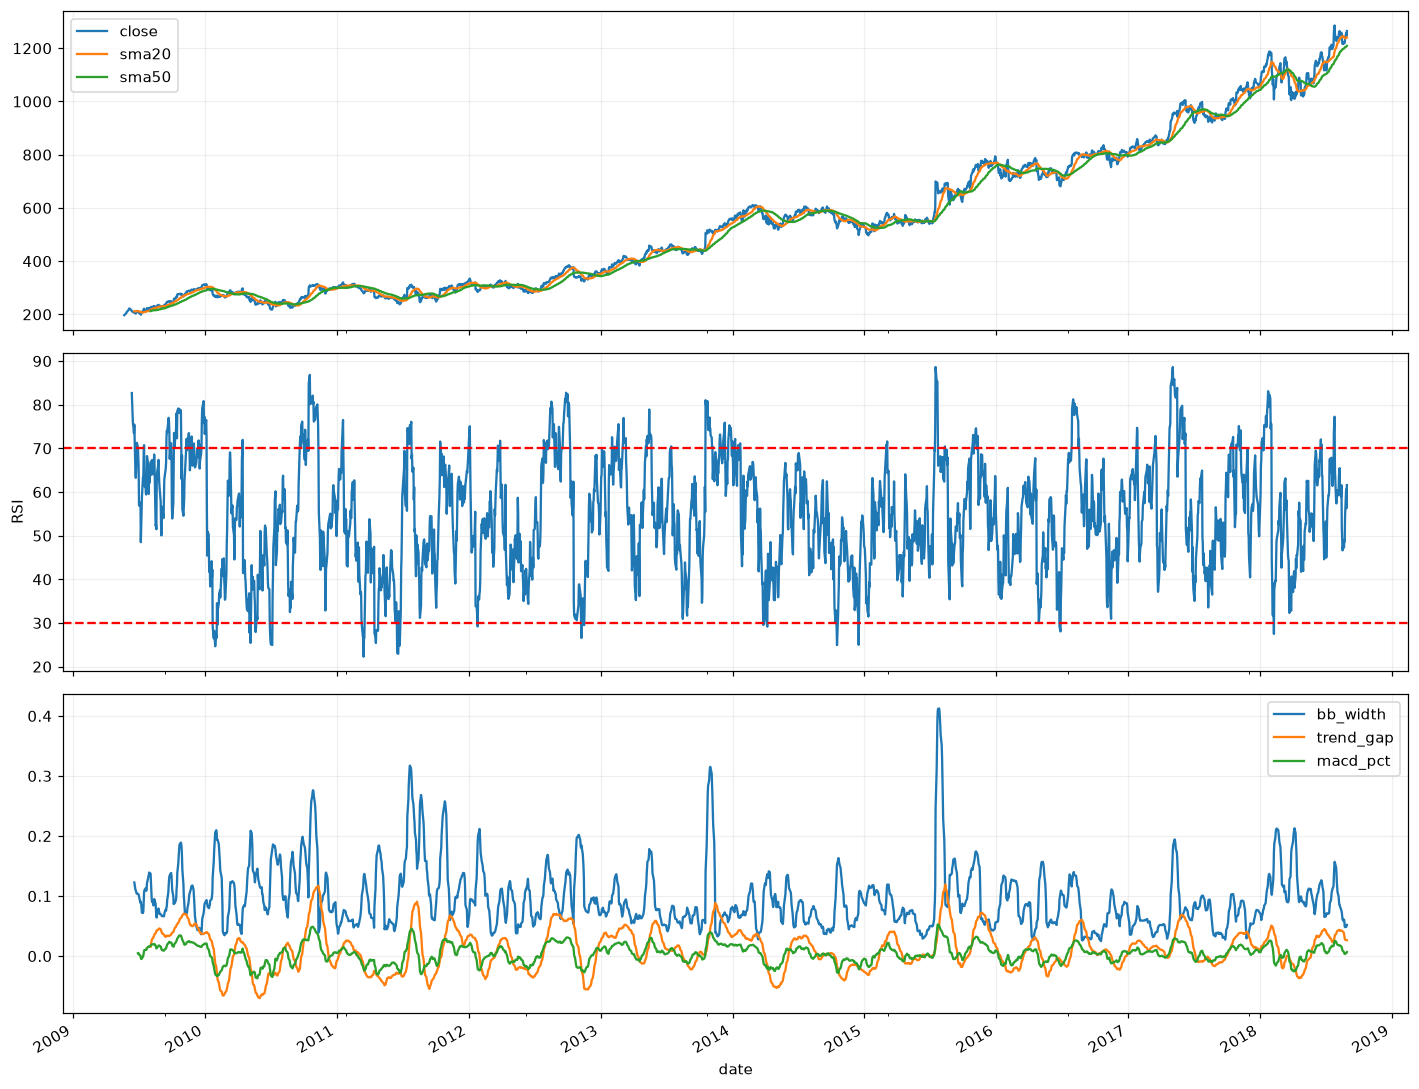

**Output interpretation.** Full-window trend features first become available on **2009-08-03**. RSI is below 30 in **2.2%** and above 70 in **13.0%** of valid rows. These threshold names describe indicator states, not guaranteed reversals. Warm-up values in the original min_periods=1 version are based on shorter histories.

In [19]:
# Use full-window indicators and explicit handling of flat RSI windows.
p=df.close
x['sma20']=p.rolling(20).mean(); x['sma50']=p.rolling(50).mean()
x['trend_gap']=x.sma20/x.sma50-1
ema12=p.ewm(span=12,adjust=False,min_periods=12).mean(); ema26=p.ewm(span=26,adjust=False,min_periods=26).mean()
x['macd']=ema12-ema26; x['macd_pct']=x.macd/p
sigma20=p.rolling(20).std(ddof=0)
x['bb_width']=4*sigma20/x.sma20
change=p.diff(); gain=change.clip(lower=0).ewm(alpha=1/14,adjust=False,min_periods=14).mean(); loss=(-change.clip(upper=0)).ewm(alpha=1/14,adjust=False,min_periods=14).mean()
x['rsi']=100-100/(1+gain/loss)
x.loc[(gain==0)&(loss==0),'rsi']=50
x['momentum5']=p.pct_change(5,fill_method=None)
features=['trend_gap','macd_pct','bb_width','rsi','momentum5','relative_volume','range_pct']
display(x[features].agg(['count','min','median','max']).T)
fig,ax=plt.subplots(3,1,figsize=(13,10),sharex=True)
x[['close','sma20','sma50']].plot(ax=ax[0]); x.rsi.plot(ax=ax[1]); ax[1].axhline(30,color='red',ls='--'); ax[1].axhline(70,color='red',ls='--'); ax[1].set_ylabel('RSI')
x[['bb_width','trend_gap','macd_pct']].plot(ax=ax[2]); finish()
explain(f'Full-window trend features first become available on **{x.trend_gap.first_valid_index().date()}**. RSI is below 30 in **{x.rsi.dropna().lt(30).mean():.1%}** and above 70 in **{x.rsi.dropna().gt(70).mean():.1%}** of valid rows. These threshold names describe indicator states, not guaranteed reversals. Warm-up values in the original min_periods=1 version are based on shorter histories.')

## 20. Chronological splits and distribution drift

A 60/20/20 chronological partition shows how distributions change.

In [20]:
# Define partitions chronologically; do not shuffle a time series.
nrows=len(x); cut1=int(.6*nrows); cut2=int(.8*nrows)
x['split']=np.where(np.arange(nrows)<cut1,'train',np.where(np.arange(nrows)<cut2,'validation','test'))
split_summary=x.groupby('split',sort=False).agg(start=('close',lambda s:s.index.min()),end=('close',lambda s:s.index.max()),rows=('close','size'),mean_return=('return','mean'),daily_volatility=('return','std'),median_volume=('volume','median'))
display(split_summary)
drift=[]
for feature in ['return']+features:
 train=x.loc[x.split=='train',feature].dropna()
 for label in ['validation','test']:
  other=x.loc[x.split==label,feature].dropna()
  drift.append({'feature':feature,'comparison':label,'train_median':train.median(),'other_median':other.median(),'KS_distance':stats.ks_2samp(train,other).statistic,'outside_train_minmax_pct':((other<train.min())|(other>train.max())).mean()*100})
drift=pd.DataFrame(drift); display(drift.sort_values('KS_distance',ascending=False))
explain(f'The largest distribution distance is **{drift.KS_distance.max():.3f}** for **{drift.loc[drift.KS_distance.idxmax(),"feature"]}** in **{drift.loc[drift.KS_distance.idxmax(),"comparison"]}**. KS distance measures the maximum gap between empirical CDFs; it does not quantify future model degradation. Train-only scaling avoids importing later distribution information.')

,start,end,rows,mean_return,daily_volatility,median_volume
split,,,,,,
train,2009-05-22,2014-12-12,1401,0.00081,0.01540,"4,451,300.00000"
validation,2014-12-15,2016-10-20,467,0.00110,0.01599,"1,807,300.00000"
test,2016-10-21,2018-08-29,467,0.00100,0.01262,"1,588,300.00000"


,feature,comparison,train_median,other_median,KS_distance,outside_train_minmax_pct
3,trend_gap,test,0.01209,0.01394,0.19459,0.00000
2,trend_gap,validation,0.01209,0.00309,0.16322,0.42827
5,macd_pct,test,0.00501,0.00687,0.16101,0.00000
7,bb_width,test,0.08701,0.07774,0.15283,0.21413
15,range_pct,test,0.01537,0.01368,0.12991,0.21413
4,macd_pct,validation,0.00501,0.00350,0.12653,1.07066
6,bb_width,validation,0.08701,0.08425,0.12122,3.85439
8,rsi,validation,54.03198,53.31326,0.10626,0.21413
9,rsi,test,54.03198,56.19082,0.10459,0.42827
1,return,test,0.00048,0.00150,0.07379,0.00000


**Output interpretation.** The largest distribution distance is **0.195** for **trend_gap** in **test**. KS distance measures the maximum gap between empirical CDFs; it does not quantify future model degradation. Train-only scaling avoids importing later distribution information.

## 21. Lagged feature associations and forward-return alignment

In [21]:
# Exclude labels that cross a partition boundary.
x['next_return']=x['return'].shift(-1)
x['target_same_split']=x.split.eq(x.split.shift(-1))
associations=[]
for label in ['train','validation','test']:
 for f in features:
  pair=x.loc[(x.split==label)&x.target_same_split,[f,'next_return']].dropna()
  associations.append({'split':label,'feature':f,'n':len(pair),'spearman':pair[f].corr(pair.next_return,method='spearman')})
assoc=pd.DataFrame(associations)
display(assoc.pivot(index='feature',columns='split',values='spearman')); display(assoc.pivot(index='feature',columns='split',values='n'))
train_assoc=assoc[assoc.split=='train']; strongest=train_assoc.loc[train_assoc.spearman.abs().idxmax()]
explain(f'The largest absolute training association is **{strongest.feature}**, with Spearman correlation **{strongest.spearman:.3f}**. Compare its sign and magnitude in later periods before interpreting it. Selecting the strongest result among several features adds selection bias; no significance or profitability claim is made.')

split,test,train,validation
feature,,,
bb_width,-0.00315,0.02533,0.04982
macd_pct,-0.11018,-0.01196,-0.11900
momentum5,0.00836,0.01823,-0.05526
range_pct,-0.02775,0.00722,-0.03105
relative_volume,-0.08687,0.02225,0.02891
rsi,-0.04291,-0.00042,-0.10851
trend_gap,-0.02384,-0.00888,-0.05820


split,test,train,validation
feature,,,
bb_width,466,1381,466
macd_pct,466,1375,466
momentum5,466,1395,466
range_pct,466,1400,466
relative_volume,466,1380,466
rsi,466,1386,466
trend_gap,466,1351,466


**Output interpretation.** The largest absolute training association is **bb_width**, with Spearman correlation **0.025**. Compare its sign and magnitude in later periods before interpreting it. Selecting the strongest result among several features adds selection bias; no significance or profitability claim is made.

## 22. Discrete state occupancy and unseen states

In [22]:
# Fit volatility cut points on training history and freeze them.
train_width=x.loc[x.split=='train','bb_width'].dropna()
edges=np.unique(train_width.quantile([1/3,2/3]).to_numpy())
st=pd.DataFrame(index=x.index)
st['trend']=np.sign(x.trend_gap)
st['rsi']=pd.cut(x.rsi,[-np.inf,30,70,np.inf],labels=[0,1,2],right=False).astype(float)
st['macd']=np.sign(x.macd_pct)
st['volatility']=pd.cut(x.bb_width,[-np.inf,*edges,np.inf],labels=False)
st['direction']=np.sign(p.diff()); st['momentum']=np.sign(x.momentum5)
valid=st.notna().all(axis=1)
states=st.loc[valid].astype(int).apply(tuple,axis=1)
train_states=set(states[x.loc[states.index,'split']=='train'])
occupancy=[]
for label in ['train','validation','test']:
 s=states[x.loc[states.index,'split']==label]; counts=s.value_counts()
 occupancy.append({'split':label,'valid_rows':len(s),'unique_states':s.nunique(),'singleton_states':counts.eq(1).sum(),'unseen_vs_train_pct':(~s.isin(train_states)).mean()*100,'top_state_share':counts.iloc[0]/len(s)})
display(pd.DataFrame(occupancy)); display(states.value_counts().head(12).rename('visits').to_frame())
explain(f'Training visits **{len(train_states)} distinct states**, against a nominal maximum of 3⁶=729 for six ternary features (many combinations are structurally rare or impossible). Sparse visits and unseen later states can leave tabular estimates poorly supported. Repeating the same episode increases updates but does not create new market histories.')

,split,valid_rows,unique_states,singleton_states,unseen_vs_train_pct,top_state_share
0,train,1352,67,8,0.00000,0.06213
1,validation,467,51,5,0.42827,0.07281
2,test,467,56,11,0.64240,0.11777


,visits
"(1, 1, 1, 0, 1, 1)",173
"(1, 1, 1, 0, -1, -1)",138
"(1, 2, 1, 2, 1, 1)",104
"(1, 1, 1, 1, -1, -1)",101
"(1, 1, 1, 1, 1, 1)",93
"(1, 1, 1, 0, -1, 1)",87
"(1, 1, 1, 1, -1, 1)",85
"(-1, 1, -1, 2, 1, 1)",85
"(1, 1, 1, 0, 1, -1)",67
"(1, 2, 1, 1, 1, 1)",67


**Output interpretation.** Training visits **67 distinct states**, against a nominal maximum of 3⁶=729 for six ternary features (many combinations are structurally rare or impossible). Sparse visits and unseen later states can leave tabular estimates poorly supported. Repeating the same episode increases updates but does not create new market histories.

## 23. What market history does the existing curriculum actually cover?

,horizon_steps,start_tick,end_tick,start_date,end_date,price_points,dataset_pct,close_change,daily_volatility
0,21,10,31,2009-06-08,2009-07-08,22,0.94218,-0.08269,0.01457
1,60,10,70,2009-06-08,2009-09-01,61,2.61242,0.03872,0.01488
2,90,10,100,2009-06-08,2009-10-14,91,3.89722,0.22005,0.01387
3,289,10,299,2009-06-08,2010-07-30,290,12.41970,0.10502,0.01563


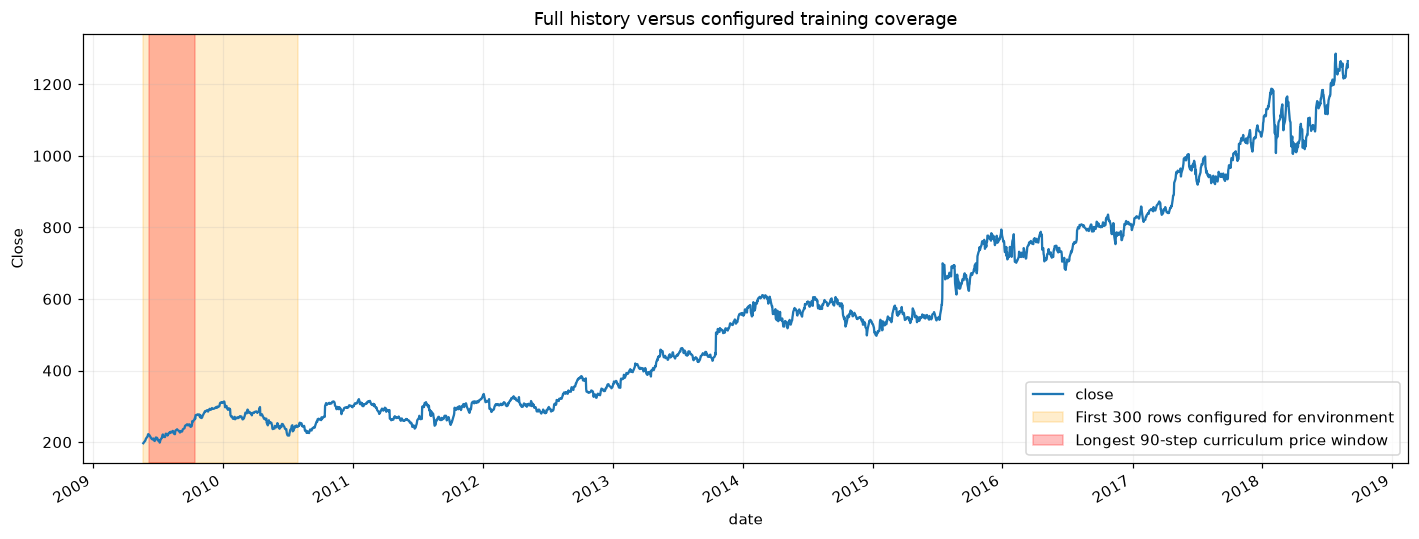

**Output interpretation.** The longest 90-step curriculum spans **2009-06-08 to 2009-10-14**, using 91 price points, only **3.9%** of the dataset. Evaluation that resets to that same window measures reuse of the same history, not chronological generalization. More episodes cannot substitute for diverse training windows and an untouched evaluation period.

In [23]:
# Map positional episode bounds back to the original source dates.
coverage=[]
start=10
for horizon in [21,60,90,289]:
 end=min(start+horizon,299)
 segment=x.iloc[start:end+1]
 coverage.append({'horizon_steps':horizon,'start_tick':start,'end_tick':end,'start_date':segment.index[0],'end_date':segment.index[-1],'price_points':len(segment),'dataset_pct':len(segment)/len(x)*100,'close_change':segment.close.iloc[-1]/segment.close.iloc[0]-1,'daily_volatility':segment.close.pct_change(fill_method=None).std()})
display(pd.DataFrame(coverage))
fig,ax=plt.subplots(figsize=(13,5)); df.close.plot(ax=ax)
ax.axvspan(df.index[0],df.index[299],color='orange',alpha=.2,label='First 300 rows configured for environment')
ax.axvspan(df.index[10],df.index[100],color='red',alpha=.25,label='Longest 90-step curriculum price window')
ax.legend(); ax.set(title='Full history versus configured training coverage',ylabel='Close'); finish()
explain(f'The longest 90-step curriculum spans **{df.index[10].date()} to {df.index[100].date()}**, using 91 price points, only **{91/len(df):.1%}** of the dataset. Evaluation that resets to that same window measures reuse of the same history, not chronological generalization. More episodes cannot substitute for diverse training windows and an untouched evaluation period.')

## 24. Compact findings generated from this run

In [24]:
# Generate the final findings from computed values, not hard-coded claims.
findings=pd.DataFrame([
 ('Dataset',f'{len(df):,} rows; {df.index[0].date()} to {df.index[-1].date()}','Retain source dates and record package version/hash.'),
 ('Date relabeling',f'{(date_comparison.difference_days!=0).sum():,} source dates differ from synthetic labels','Rebuild calendar features using source dates.'),
 ('Completeness',f'{df.isna().sum().sum()} missing cells','Do not add artificial holiday observations.'),
 ('Adjustment',f'Close equals Adj Close: {np.allclose(df.close,df.adj_close)}','Adjustment information is not independently verified.'),
 ('Daily risk',f'Std {r.std():.2%}; excess kurtosis {r.kurt():.2f}','Preserve extremes and assess sensitivity.'),
 ('Drawdown',f'Maximum {drawdown.min():.2%}','Terminal growth does not describe interim losses.'),
 ('Dependence',f'Absolute-return lag-1 correlation {r.abs().autocorr(1):.3f}','Use time-aware evaluation and dependence-aware uncertainty.'),
 ('Training support',f'{len(train_states)} distinct training states','Inspect sparse and unseen states before trusting tabular estimates.'),
 ('Curriculum coverage',f'Longest reset window: {91/len(df):.1%} of price rows','Broaden training windows; evaluate on later untouched data.')
],columns=['topic','observed_evidence','implication'])
display(findings)
explain('This EDA characterizes the supplied historical snapshot and identifies issues relevant to the experiment. It does not establish a deployable trading strategy. Because every chronological partition has now been explored, reserve new data before making a final out-of-sample claim.')

,topic,observed_evidence,implication
0,Dataset,"2,335 rows; 2009-05-22 to 2018-08-29",Retain source dates and record package version...
1,Date relabeling,"2,335 source dates differ from synthetic labels",Rebuild calendar features using source dates.
2,Completeness,0 missing cells,Do not add artificial holiday observations.
3,Adjustment,Close equals Adj Close: True,Adjustment information is not independently ve...
4,Daily risk,Std 1.50%; excess kurtosis 14.47,Preserve extremes and assess sensitivity.
5,Drawdown,Maximum -30.42%,Terminal growth does not describe interim losses.
6,Dependence,Absolute-return lag-1 correlation 0.073,Use time-aware evaluation and dependence-aware...
7,Training support,67 distinct training states,Inspect sparse and unseen states before trusti...
8,Curriculum coverage,Longest reset window: 3.9% of price rows,Broaden training windows; evaluate on later un...


**Output interpretation.** This EDA characterizes the supplied historical snapshot and identifies issues relevant to the experiment. It does not establish a deployable trading strategy. Because every chronological partition has now been explored, reserve new data before making a final out-of-sample claim.

## 25. Practical next steps for the existing learning notebook

1. **Keep original dates.** Replace the index-discarding/date-generation sequence with an explicit preservation of the package’s date index.
2. **Define price semantics.** Verify adjustment and corporate-action conventions before interpreting overnight shocks or total returns; do not mix adjusted close with unadjusted OHLC in a decomposition.
3. **Require indicator warm-up.** Begin episodes after enough preceding history; distinguish structural warm-up NaNs from missing input data.
4. **Match information timing.** Confirm which tick each observation ends on and when an action is executed. Indicators using the current close/final volume must not influence a fill that occurs before those values are known.
5. **Use diverse chronological windows.** Sample episode starts within training data, retain preceding observation context, and prevent reward horizons from crossing split boundaries. Fit scalers and bins using training data only.
6. **Audit sparse states.** Track visits by state/action, unseen-state fallback behavior, and state-label stability. A larger number of episodes on one path does not provide independent evidence.
